# Step 5b - Kalman Filter Evaluation

**Run this notebook in VSCode after running the Kalman script locally.**

### Steps:
1. Run `python src/aero_fusion/step5_kalman.py`
2. Confirm these files exist under `artifacts/step5_kalman/`:
   - `test_summary.json`
   - `test_predictions.npz`
   - `per_flight_metrics_test.csv`
   - `val_tuning_results.csv`
3. Run this notebook top to bottom

### Notes
- The Kalman filter uses the same train/val/test split logic as the GRU.
- The GRU trains directly on Step 4 `npz` tensors.
- The Kalman filter uses Step 4 split metadata plus cleaned Step 2 measurements.
- In the current stable configuration, the Kalman context is the local 60-second resampled cleaned trajectory around the gap.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name in ('notebooks', 'src') else Path.cwd()
STEP5K_ROOT  = PROJECT_ROOT / 'artifacts' / 'step5_kalman'

plt.style.use('seaborn-v0_8-whitegrid')
print(f'Kalman root: {STEP5K_ROOT}')
print(f'Exists: {STEP5K_ROOT.exists()}')

Kalman root: c:\Users\ANTOINE\OneDrive\Desktop\AeroEngineering - Final Version\artifacts\step5_kalman
Exists: True


In [2]:
required = [
    STEP5K_ROOT / 'test_summary.json',
    STEP5K_ROOT / 'test_predictions.npz',
    STEP5K_ROOT / 'per_flight_metrics_test.csv',
    STEP5K_ROOT / 'val_tuning_results.csv',
]

missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError('Missing Kalman outputs. Run step5_kalman.py first:\n' + '\n'.join(missing))

print('All required Kalman output files found.')

All required Kalman output files found.


In [3]:
summary = json.loads((STEP5K_ROOT / 'test_summary.json').read_text(encoding='utf-8'))
preds = np.load(STEP5K_ROOT / 'test_predictions.npz', allow_pickle=True)
per_flight_df = pd.read_csv(STEP5K_ROOT / 'per_flight_metrics_test.csv')
tuning_df = pd.read_csv(STEP5K_ROOT / 'val_tuning_results.csv')

pred_lat = preds['pred_lat']
pred_lon = preds['pred_lon']
true_lat = preds['true_lat']
true_lon = preds['true_lon']
baseline_lat = preds['baseline_lat']
baseline_lon = preds['baseline_lon']
mask = preds['mask']
adsc_tau = preds['adsc_tau']
segment_ids = preds['segment_ids']

N = pred_lat.shape[0]
print(f'Loaded {N} test flights')
print(json.dumps(summary, indent=2))

Loaded 5 test flights
{
  "config": {
    "step2_root": "C:\\Users\\ANTOINE\\OneDrive\\Desktop\\AeroEngineering - Final Version\\artifacts\\step2_clean",
    "step4_dataset_root": "C:\\Users\\ANTOINE\\OneDrive\\Desktop\\AeroEngineering - Final Version\\artifacts\\step4_ml_dataset\\dataset",
    "output_root": "C:\\Users\\ANTOINE\\OneDrive\\Desktop\\AeroEngineering - Final Version\\artifacts\\step5_kalman",
    "context_mode": "native_clean",
    "resample_seconds": 60,
    "before_context_limit": null,
    "after_context_limit": null,
    "tuning_grid": "deep",
    "max_flights_per_split": 5,
    "tune_on_split": "val",
    "verbose": true,
    "clean_existing_output": true
  },
  "prepared_counts": {
    "train": 5,
    "val": 5,
    "test": 5
  },
  "selected_params": {
    "measurement_std_m": 250.0,
    "accel_std_along_mps2": 0.05,
    "accel_std_cross_mps2": 0.005
  },
  "validation_summary": {
    "split": "val",
    "n_flights": 5,
    "kalman_mean_error_km": 77.24676273970171,

## Selected Kalman Configuration

In [4]:
config_df = pd.DataFrame([
    {'field': k, 'value': v}
    for k, v in summary['config'].items()
])
selected_df = pd.DataFrame([
    {'parameter': k, 'value': v}
    for k, v in summary['selected_params'].items()
])

display(config_df)
display(selected_df)

,field,value
0,step2_root,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...
1,step4_dataset_root,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...
2,output_root,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...
3,context_mode,native_clean
4,resample_seconds,60
5,before_context_limit,None
6,after_context_limit,None
7,tuning_grid,deep
8,max_flights_per_split,5
9,tune_on_split,val


,parameter,value
0,measurement_std_m,250.000
1,accel_std_along_mps2,0.050
2,accel_std_cross_mps2,0.005


## Validation Tuning Results

,candidate_rank,measurement_std_m,accel_std_along_mps2,accel_std_cross_mps2,split,n_flights,kalman_mean_error_km,kalman_median_error_km,kalman_p90_error_km,baseline_mean_error_km,baseline_median_error_km,baseline_p90_error_km,improvement_mean_pct,improvement_median_pct
0,76,250.0,0.05,0.005,val,5,77.246763,36.180301,204.189419,71.984595,75.4715,99.301881,-7.310130,52.060976
1,125,500.0,0.10,0.010,val,5,77.246773,36.180301,204.189419,71.984595,75.4715,99.301881,-7.310145,52.060976
2,75,250.0,0.05,0.003,val,5,77.279023,35.942309,201.557306,71.984595,75.4715,99.301881,-7.354946,52.376316
3,30,100.0,0.02,0.020,val,5,77.544061,39.280648,210.338759,71.984595,75.4715,99.301881,-7.723133,47.953004
4,29,100.0,0.02,0.010,val,5,77.829003,36.983406,211.958003,71.984595,75.4715,99.301881,-8.118970,50.996858
5,78,250.0,0.05,0.020,val,5,78.029537,37.087457,211.830734,71.984595,75.4715,99.301881,-8.397550,50.858990
6,81,250.0,0.10,0.003,val,5,78.196994,43.826223,203.224119,71.984595,75.4715,99.301881,-8.630178,41.930103
7,27,100.0,0.02,0.003,val,5,78.351106,38.675902,206.922081,71.984595,75.4715,99.301881,-8.844269,48.754295
8,82,250.0,0.10,0.005,val,5,78.391673,44.060879,205.834587,71.984595,75.4715,99.301881,-8.900623,41.619182
9,28,100.0,0.02,0.005,val,5,78.508545,38.472859,210.128509,71.984595,75.4715,99.301881,-9.062980,49.023328


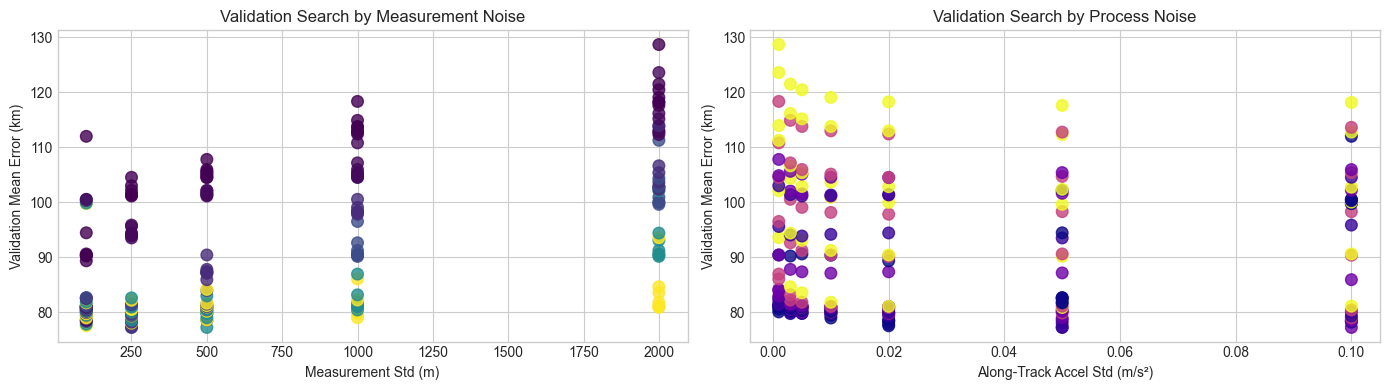

In [5]:
top_tuning = tuning_df.sort_values('kalman_mean_error_km').head(10).copy()
display(top_tuning)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(
    tuning_df['measurement_std_m'],
    tuning_df['kalman_mean_error_km'],
    c=tuning_df['accel_std_cross_mps2'],
    cmap='viridis',
    s=70,
    alpha=0.8,
)
axes[0].set_xlabel('Measurement Std (m)')
axes[0].set_ylabel('Validation Mean Error (km)')
axes[0].set_title('Validation Search by Measurement Noise')

axes[1].scatter(
    tuning_df['accel_std_along_mps2'],
    tuning_df['kalman_mean_error_km'],
    c=tuning_df['measurement_std_m'],
    cmap='plasma',
    s=70,
    alpha=0.8,
)
axes[1].set_xlabel('Along-Track Accel Std (m/s²)')
axes[1].set_ylabel('Validation Mean Error (km)')
axes[1].set_title('Validation Search by Process Noise')

plt.tight_layout()
plt.show()

## Kalman vs Baseline Test Results

,metric,value
0,Kalman Mean Error (km),43.122368
1,Kalman Median Error (km),39.622943
2,Baseline Mean Error (km),70.955125
3,Baseline Median Error (km),81.241355
4,Improvement Mean (%),39.225858
5,Improvement Median (%),51.228111


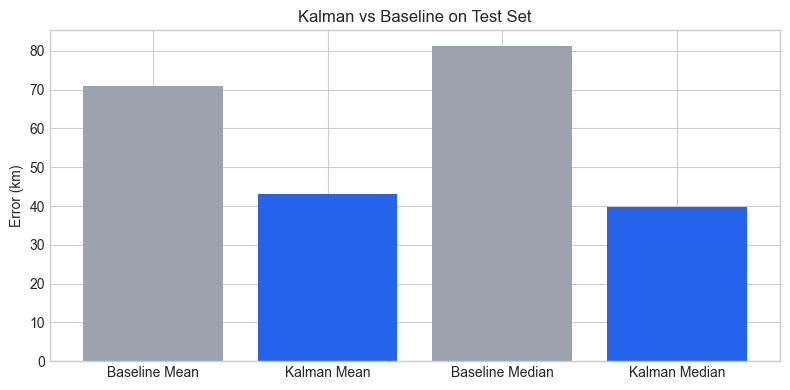

In [6]:
test_summary = summary['test_summary']
test_metrics_df = pd.DataFrame([
    ['Kalman Mean Error (km)', test_summary['kalman_mean_error_km']],
    ['Kalman Median Error (km)', test_summary['kalman_median_error_km']],
    ['Baseline Mean Error (km)', test_summary['baseline_mean_error_km']],
    ['Baseline Median Error (km)', test_summary['baseline_median_error_km']],
    ['Improvement Mean (%)', test_summary['improvement_mean_pct']],
    ['Improvement Median (%)', test_summary['improvement_median_pct']],
], columns=['metric', 'value'])
display(test_metrics_df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    ['Baseline Mean', 'Kalman Mean', 'Baseline Median', 'Kalman Median'],
    [
        test_summary['baseline_mean_error_km'],
        test_summary['kalman_mean_error_km'],
        test_summary['baseline_median_error_km'],
        test_summary['kalman_median_error_km'],
    ],
    color=['#9ca3af', '#2563eb', '#9ca3af', '#2563eb'],
)
ax.set_ylabel('Error (km)')
ax.set_title('Kalman vs Baseline on Test Set')
plt.tight_layout()
plt.show()

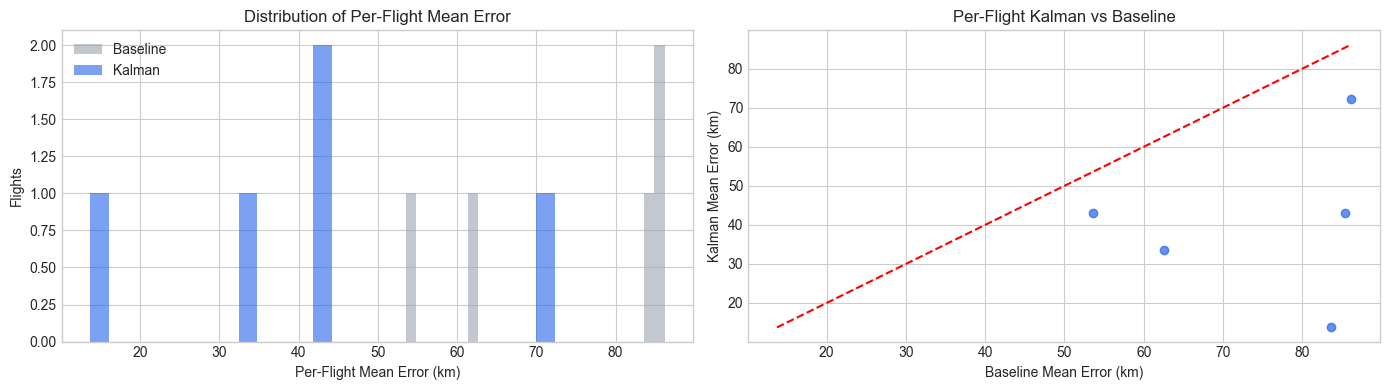

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(per_flight_df['baseline_mean_error_km'], bins=25, alpha=0.6, label='Baseline', color='#9ca3af')
axes[0].hist(per_flight_df['kalman_mean_error_km'], bins=25, alpha=0.6, label='Kalman', color='#2563eb')
axes[0].set_xlabel('Per-Flight Mean Error (km)')
axes[0].set_ylabel('Flights')
axes[0].set_title('Distribution of Per-Flight Mean Error')
axes[0].legend()

axes[1].scatter(
    per_flight_df['baseline_mean_error_km'],
    per_flight_df['kalman_mean_error_km'],
    alpha=0.7,
    color='#2563eb',
)
lims = [
    min(per_flight_df['baseline_mean_error_km'].min(), per_flight_df['kalman_mean_error_km'].min()),
    max(per_flight_df['baseline_mean_error_km'].max(), per_flight_df['kalman_mean_error_km'].max()),
]
axes[1].plot(lims, lims, linestyle='--', color='red')
axes[1].set_xlabel('Baseline Mean Error (km)')
axes[1].set_ylabel('Kalman Mean Error (km)')
axes[1].set_title('Per-Flight Kalman vs Baseline')

plt.tight_layout()
plt.show()

## Best and Worst Kalman Flights

In [8]:
best_flights = per_flight_df.sort_values('improvement_mean_pct', ascending=False).head(10)
worst_flights = per_flight_df.sort_values('improvement_mean_pct', ascending=True).head(10)

print('Best Kalman improvements:')
display(best_flights)
print('Worst Kalman improvements:')
display(worst_flights)

Best Kalman improvements:


,split,segment_id,n_waypoints,kalman_mean_error_km,kalman_median_error_km,baseline_mean_error_km,baseline_median_error_km,improvement_mean_pct,improvement_median_pct
4,test,20230709_040187_085652_093702,5,13.729203,16.218574,83.603023,91.024555,83.578102,82.182199
0,test,20230708_0101e0_115103_124631,5,43.163680,50.519934,85.350867,98.329219,49.427956,48.621649
2,test,20230708_ac21af_135232_145532,6,33.470238,33.713781,62.535938,68.783266,46.478391,50.985488
1,test,20230708_a5d1a2_122902_161821,11,43.158313,43.399652,53.563371,44.079449,19.425696,1.542211
3,test,20230708_c02ec1_092844_101850,7,72.304750,75.052820,86.184578,89.795312,16.104770,16.417885


Worst Kalman improvements:


,split,segment_id,n_waypoints,kalman_mean_error_km,kalman_median_error_km,baseline_mean_error_km,baseline_median_error_km,improvement_mean_pct,improvement_median_pct
3,test,20230708_c02ec1_092844_101850,7,72.304750,75.052820,86.184578,89.795312,16.104770,16.417885
1,test,20230708_a5d1a2_122902_161821,11,43.158313,43.399652,53.563371,44.079449,19.425696,1.542211
2,test,20230708_ac21af_135232_145532,6,33.470238,33.713781,62.535938,68.783266,46.478391,50.985488
0,test,20230708_0101e0_115103_124631,5,43.163680,50.519934,85.350867,98.329219,49.427956,48.621649
4,test,20230709_040187_085652_093702,5,13.729203,16.218574,83.603023,91.024555,83.578102,82.182199


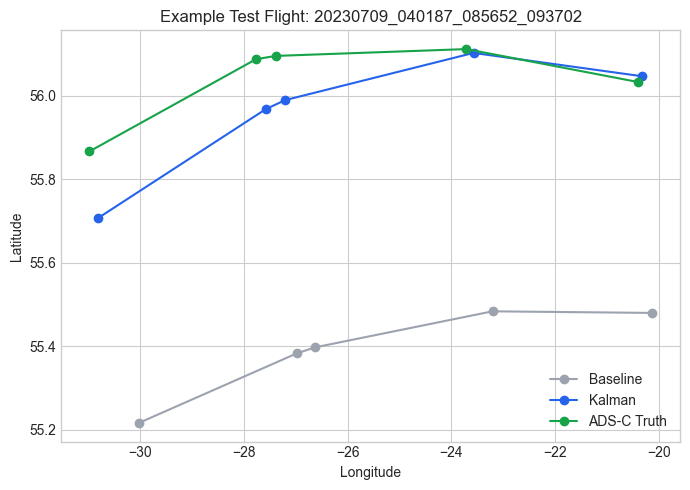

In [9]:
flight_idx = int(np.argmax(per_flight_df['improvement_mean_pct'].to_numpy()))
seg_id = segment_ids[flight_idx]
valid = mask[flight_idx] > 0

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(baseline_lon[flight_idx][valid], baseline_lat[flight_idx][valid], marker='o', label='Baseline', color='#9ca3af')
ax.plot(pred_lon[flight_idx][valid], pred_lat[flight_idx][valid], marker='o', label='Kalman', color='#2563eb')
ax.plot(true_lon[flight_idx][valid], true_lat[flight_idx][valid], marker='o', label='ADS-C Truth', color='#16a34a')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Example Test Flight: {seg_id}')
ax.legend()
plt.tight_layout()
plt.show()